In [35]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from bisect import bisect_left
from scipy import stats
import pandas as pd
from typing import List

# Allow importing eval.metrics from the scripts/ directory
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from eval.metrics import read_traj_metrics  # available for instance-level analysis

In [ ]:
# ── Evaluation directories ────────────────────────────────────────────────────
# Set EVAL_DIR_B = None  → single-eval report for EVAL_DIR_A only.
# Set EVAL_DIR_B to a path → side-by-side comparison (A = original, B = metamorphic).

# usually, original
EVAL_DIR_A = "/Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/results/original/benchmarks_4_easy_gpt5.4_runs_12"
# usually, metamorphic (change to None or another path)
EVAL_DIR_B = None # "/Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/results/metamorphic/benchmarks_3_easy_gpt5.4_runs_12"

LABEL_A = "Original"
LABEL_B = "Metamorphic"

# Filter to a specific subset of instances (set None to no-op)
INSTANCE_IDS = [
    "mockito__mockito-3129",
    "fasterxml__jackson-databind-1923",
    "fasterxml__jackson-core-183"
]
# INSTANCE_IDS = None


# ── Plot styling ──────────────────────────────────────────────────────────────
COLOR_A    = "#4C72B0"   # blue  — eval A
COLOR_B    = "#DD8452"   # orange — eval B
ALPHA_BAND = 0.15        # opacity of ±std shaded bands

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "axes.titlesize":    11,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
})

print(f"Mode: {'comparison' if EVAL_DIR_B is not None else 'single'}")
print(f"  A = {Path(EVAL_DIR_A).name!r}  ({LABEL_A})")
if EVAL_DIR_B is not None:
    print(f"  B = {Path(EVAL_DIR_B).name!r}  ({LABEL_B})")

Mode: comparison
  A = 'benchmarks_4_easy_gpt5.4_runs_12'  (Original)
  B = 'benchmarks_3_easy_gpt5.4_runs_12'  (Metamorphic)


In [37]:
# ─── Data loading ─────────────────────────────────────────────────────────────

def load_metrics(dirpath, filename: str = "metrics_summary.json") -> dict:
    """Load metrics_summary.json from an eval results directory."""
    path = Path(dirpath) / filename
    if not path.exists():
        raise FileNotFoundError(f"metrics_summary.json not found in: {dirpath}")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
        return data


def load_instance_observations(dirpath, instance_ids=None) -> dict:
    """
    Walk eval_dir/run-*/result.json and collect per-instance agent metrics.

    Returns a dict of field → list (one entry per instance across all runs):
        instance_cost, api_calls, tokens_sent, tokens_received, tokens_total

    instance_ids: if not None, only include entries whose instance_id is in this list.
    Runs with a missing or empty execution list are silently skipped.
    """
    _iids = set(instance_ids) if instance_ids is not None else None
    obs = {f: [] for f in ("instance_cost", "api_calls",
                            "tokens_sent", "tokens_received", "tokens_total")}
    for path in sorted(Path(dirpath).glob("run-*/result.json")):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for inst in data.get("agent", {}).get("metrics", {}).get("execution", []):
            if _iids is not None and inst.get("instance_id") not in _iids:
                continue
            for field in ("instance_cost", "api_calls", "tokens_sent", "tokens_received"):
                if field in inst:
                    obs[field].append(inst[field])
            sent = inst.get("tokens_sent")
            recv = inst.get("tokens_received")
            if sent is not None and recv is not None:
                obs["tokens_total"].append(sent + recv)
    return obs



def validate_metrics(metrics: dict, label: str) -> list:
    """
    Return a list of warning strings for data quality issues:
    - Runs where total_instances < n_instances_per_run (incomplete eval run, pass rate may be inflated)
    - Runs with n_missing > 0 in agent metrics (missing .traj files)
    """
    issues = []
    expected = metrics.get("n_instances_per_run")

    for run in metrics.get("per_run", []):
        run_num = run["run_number"]
        ev = run.get("evaluation")
        if ev and expected is not None and ev["total_instances"] < expected:
            issues.append(
                f"[{label}] Run {run_num}: only {ev['total_instances']} of "
                f"{expected} instances were evaluated — pass rate may be inflated."
            )
        ag = run.get("agent")
        if ag and ag.get("n_missing", 0) > 0:
            issues.append(
                f"[{label}] Run {run_num}: {ag['n_missing']} trajectory file(s) missing "
                "— agent metrics are incomplete."
            )
    return issues


def get_per_run_pass_rates(metrics: dict) -> list:
    """Extract per_run[i].evaluation.pass_rate values in run order."""
    return [
        run["evaluation"]["pass_rate"]
        for run in metrics["per_run"]
        if run.get("evaluation") is not None
    ]


def get_per_run_agent_field(metrics: dict, field: str) -> list:
    """Extract per_run[i].agent.{field}.avg values in run order."""
    return [
        run["agent"][field]["avg"]
        for run in metrics["per_run"]
        if run.get("agent") and field in run["agent"]
    ]


def get_per_run_tokens_total(metrics: dict) -> list:
    """
    Return per-run total token counts (tokens_sent + tokens_received) derived
    from per_run data.  tokens_total is not stored in metrics_summary.json; it
    is computed here for plotting purposes.
    """
    result = []
    for run in metrics["per_run"]:
        ag       = run.get("agent", {})
        sent     = ag.get("tokens_sent",     {}).get("avg")
        received = ag.get("tokens_received", {}).get("avg")
        if sent is not None and received is not None:
            result.append(sent + received)
    return result


def get_run_numbers(metrics: dict) -> list:
    """Return the run_number list from per_run."""
    return [r["run_number"] for r in metrics["per_run"]]


# p-value related metrics and loading
def load_instance_observations_by_id(dirpath, instance_ids=None) -> dict:
    """
    Walk eval_dir/run-*/result.json and collect per-instance agent metrics,
    grouped by instance_id.

    instance_ids: if not None, only include entries whose instance_id is in this list.
    Returns: dict[instance_id → dict[field → list]]
    """
    _iids = set(instance_ids) if instance_ids is not None else None
    obs = {}
    for path in sorted(Path(dirpath).glob("run-*/result.json")):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for inst in data.get("agent", {}).get("metrics", {}).get("execution", []):
            iid = inst.get("instance_id")
            if iid is None:
                continue
            if _iids is not None and iid not in _iids:
                continue
            if iid not in obs:
                obs[iid] = {f: [] for f in ("instance_cost", "api_calls",
                                             "tokens_sent", "tokens_received", "tokens_total")}
            for field in ("instance_cost", "api_calls", "tokens_sent", "tokens_received"):
                if field in inst:
                    obs[iid][field].append(inst[field])
            sent = inst.get("tokens_sent")
            recv = inst.get("tokens_received")
            if sent is not None and recv is not None:
                obs[iid]["tokens_total"].append(sent + recv)
    return obs


def _agent_id_to_eval_id(agent_id: str) -> str:
    """Convert agent instance_id to eval instance_id format.

    'mockito__mockito-3129' -> 'mockito/mockito:pr-3129'
    'alibaba__fastjson2-82' -> 'alibaba/fastjson2:pr-82'
    """
    org, rest = agent_id.split("__", 1)   # rest = 'repo-number'
    idx = rest.rfind("-")                  # last dash separates repo from PR number
    repo = rest[:idx]
    number = rest[idx + 1:]
    return f"{org}/{repo}:pr-{number}"


def load_instance_pass_rates_by_id(dirpath, instance_ids=None) -> dict:
    """
    Walk eval_dir/run-*/result.json and collect per-run pass/fail (0/1) for
    every instance_id, keyed in agent format ('org__repo-number').

    instance_ids: if not None, only include entries whose instance_id is in this list.
    Returns: dict[agent_instance_id → list[int]]
    """
    _iids = set(instance_ids) if instance_ids is not None else None
    outcomes: dict[str, list[int]] = {}
    for path in sorted(Path(dirpath).glob("run-*/result.json")):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        resolved_eval_ids = set(
            data.get("evaluation", {})
                .get("metrics", {})
                .get("summary", {})
                .get("resolved_ids", [])
        )
        for inst in data.get("agent", {}).get("metrics", {}).get("execution", []):
            agent_iid = inst.get("instance_id")
            if agent_iid is None:
                continue
            if _iids is not None and agent_iid not in _iids:
                continue
            eval_iid = _agent_id_to_eval_id(agent_iid)
            resolved = 1 if eval_iid in resolved_eval_ids else 0
            outcomes.setdefault(agent_iid, []).append(resolved)
    return outcomes



def load_filtered_metrics(dirpath, instance_ids) -> dict:
    """
    Recompute per-run agent averages and pass rate from run-i/result.json,
    restricted to instance_ids.

    Returns a dict compatible with get_per_run_agent_field, get_per_run_pass_rates,
    get_per_run_tokens_total, and plot_pass_rate_distribution.
    Runs with no matching execution entries are included with agent=None.
    """
    _iids_agent = set(instance_ids)
    _iids_eval  = {_agent_id_to_eval_id(iid) for iid in instance_ids}

    per_run           = []
    pass_rate_per_run = []

    for path in sorted(Path(dirpath).glob("run-*/result.json")):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        run_number = data.get("run_number", len(per_run) + 1)

        # Agent: filter execution entries to instance_ids
        execution = [
            inst for inst in
            data.get("agent", {}).get("metrics", {}).get("execution", [])
            if inst.get("instance_id") in _iids_agent
        ]

        agent = None
        if execution:
            def _avg(field, _ex=execution):
                vals = [e[field] for e in _ex if field in e]
                return sum(vals) / len(vals) if vals else None
            agent = {
                "instance_cost":   {"avg": _avg("instance_cost")},
                "api_calls":       {"avg": _avg("api_calls")},
                "tokens_sent":     {"avg": _avg("tokens_sent")},
                "tokens_received": {"avg": _avg("tokens_received")},
            }

        # Evaluation: recount resolved/submitted within instance_ids
        ev = data.get("evaluation", {}).get("metrics", {}).get("summary", {})
        submitted_eval = set(ev.get("submitted_ids", []))
        resolved_eval  = set(ev.get("resolved_ids",  []))

        filtered_total    = len(_iids_eval & submitted_eval)
        filtered_resolved = len(_iids_eval & resolved_eval)
        pass_rate = (filtered_resolved / filtered_total * 100) if filtered_total > 0 else 0.0

        per_run.append({
            "run_number": run_number,
            "agent":      agent,
            "evaluation": {"pass_rate": pass_rate, "total_instances": filtered_total},
        })
        pass_rate_per_run.append({
            "run_number": run_number,
            "resolved":   filtered_resolved,
            "total":      filtered_total,
            "pass_rate":  pass_rate,
        })

    pr_vals = [r["pass_rate"] for r in pass_rate_per_run]
    pr_avg  = sum(pr_vals) / len(pr_vals) if pr_vals else None
    pr_std  = (sum((v - pr_avg) ** 2 for v in pr_vals) / max(len(pr_vals) - 1, 1)) ** 0.5 \
              if len(pr_vals) >= 2 else None

    return {
        "per_run":             per_run,
        "n_instances_per_run": len(instance_ids),
        "pass_rate": {
            "avg":     pr_avg,
            "std":     pr_std,
            "per_run": pass_rate_per_run,
        },
    }





def _vd_a12(treatment, control):
    """
    Vargha-Delaney A12 effect size (Vargha & Delaney, 2000).

    A12 = probability that a random value from `treatment` exceeds one from `control`.
    A12 = 0.5 → no difference.  A12 > 0.5 → treatment tends to be larger.

    Magnitude thresholds (Hess & Kromrey, 2004):
      |scaled_A| > 0.474 → large
      |scaled_A| > 0.33  → medium
      |scaled_A| > 0.147 → small
      otherwise          → negligible
    where scaled_A = (A12 - 0.5) * 2.

    Uses the rankdata formula from Gist 2 by @jacksonpradolima (numerically stable).
    Works for unequal-length lists (the equal-length guard in the original gist is
    overly strict — the formula is valid for m ≠ n).
    """
    m = len(treatment)
    n = len(control)
    r = stats.rankdata(list(treatment) + list(control))
    r1 = sum(r[:m])
    A = (2 * r1 - m * (m + 1)) / (2 * n * m)
    levels = [0.147, 0.33, 0.474]          # Hess & Kromrey 2004
    magnitudes = ["negligible", "small", "medium", "large"]
    scaled_A = (A - 0.5) * 2
    magnitude = magnitudes[bisect_left(levels, abs(scaled_A))]
    return A, magnitude


def _wilcoxon_pvalue(data_a, data_b):
    """
    Two-sided Wilcoxon rank-sum test (= Mann-Whitney U test) for two independent samples.
    Returns the p-value. Uses scipy.stats.mannwhitneyu with alternative='two-sided'.
    """
    _, p = stats.mannwhitneyu(data_a, data_b, alternative="two-sided")
    return p

In [38]:
# ─── Single-eval plots ────────────────────────────────────────────────────────

def plot_pass_rate_distribution(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
    ax=None,
) -> None:
    """
    Bar chart of per-run pass rates with avg ± std band.
    Anomalous runs (total_instances < n_instances_per_run) are marked with '*'.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 3.5))

    expected   = metrics.get("n_instances_per_run")
    pr         = metrics.get("pass_rate", {})
    avg        = pr.get("avg")
    std        = pr.get("std")
    per_run    = pr.get("per_run", [])
    run_nums   = [r["run_number"] for r in per_run]
    pass_rates = [r["pass_rate"]  for r in per_run]
    totals     = [r["total"]      for r in per_run]

    xs = np.arange(len(run_nums))
    ax.bar(xs, pass_rates, color=color, alpha=0.75, width=0.6, zorder=3)

    for i, (rate, total) in enumerate(zip(pass_rates, totals)):
        if expected is not None and total < expected:
            ax.text(xs[i], rate + 1.5, "*", ha="center", color="crimson", fontsize=13, zorder=5)

    if avg is not None:
        ax.axhline(avg, color=color, linewidth=1.5, linestyle="--", label=f"avg = {avg:.1f}%")
    if avg is not None and std is not None:
        ax.axhspan(avg - std, avg + std, color=color, alpha=ALPHA_BAND, label=f"±std ({std:.1f}%)")

    ax.set_xticks(xs)
    ax.set_xticklabels([f"R{n}" for n in run_nums])
    ax.set_ylim(0, 110)
    ax.set_ylabel("Pass rate (%)")
    ax.set_title(f"{label} — pass rate per run")
    ax.legend(fontsize=8)

    n_inst = metrics.get("n_instances_per_run", "?")
    ax.text(0.01, 0.97, f"M = {n_inst} instances/run  |  * = incomplete eval run",
            transform=ax.transAxes, va="top", fontsize=7, color="gray")


def _plot_field_line(ax, xs, values, avg_val, std_val, color, title):
    """Internal helper: draw a single per-run line with avg ± std band."""
    ax.plot(xs, values, marker="o", color=color, linewidth=1.5, markersize=5, zorder=3)
    if avg_val is not None:
        ax.axhline(avg_val, color=color, linestyle="--", linewidth=1, alpha=0.6)
    if avg_val is not None and std_val is not None:
        ax.axhspan(avg_val - std_val, avg_val + std_val, color=color, alpha=ALPHA_BAND)
    ax.set_title(title)


def plot_agent_cost_api_per_run(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×2 subplot: per-run line charts for instance_cost and api_calls.

    instance_cost (not total_cost) is the primary cost metric: it is the
    marginal cost for a single instance's API calls, independent of session
    ordering.  total_cost accumulates context across multiple instances in the
    same session and is not comparable across different session sizes.
    """
    fields = ("instance_cost", "api_calls")
    titles = ("Instance cost (USD)", "API calls")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    fig.suptitle(f"{label} — cost & API calls per run", fontsize=11, y=1.02)

    run_nums = get_run_numbers(metrics)
    var      = metrics.get("run_variability", {})
    xs       = np.arange(len(run_nums))

    for ax, field, title in zip(axes, fields, titles):
        values  = get_per_run_agent_field(metrics, field)
        fv      = var.get(field, {})
        _plot_field_line(ax, xs, values, fv.get("avg_of_run_avgs"), fv.get("std_of_run_avgs"),
                         color, title)
        ax.set_xticks(xs)
        ax.set_xticklabels([f"R{n}" for n in run_nums])

    plt.tight_layout()


def plot_agent_tokens_per_run(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×3 subplot: per-run line charts for tokens_sent, tokens_received, and
    tokens_total (= sent + received, derived — not stored in the JSON).

    Shaded band shows ±std_of_run_avgs for stored fields; for tokens_total
    the band is derived from the per-run totals using numpy.
    """
    run_nums      = get_run_numbers(metrics)
    var           = metrics.get("run_variability", {})
    xs            = np.arange(len(run_nums))
    tokens_total  = get_per_run_tokens_total(metrics)

    # Derive avg and std for tokens_total from per-run values
    total_avg = float(np.mean(tokens_total)) if tokens_total else None
    total_std = float(np.std(tokens_total, ddof=1)) if len(tokens_total) >= 2 else None

    FIELDS = [
        ("tokens_sent",     "Tokens sent",     get_per_run_agent_field(metrics, "tokens_sent"),
         var.get("tokens_sent", {}).get("avg_of_run_avgs"),
         var.get("tokens_sent", {}).get("std_of_run_avgs")),
        ("tokens_received", "Tokens received", get_per_run_agent_field(metrics, "tokens_received"),
         var.get("tokens_received", {}).get("avg_of_run_avgs"),
         var.get("tokens_received", {}).get("std_of_run_avgs")),
        ("tokens_total",    "Tokens total",    tokens_total,
         total_avg, total_std),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    fig.suptitle(f"{label} — tokens per run", fontsize=11, y=1.02)

    for ax, (_, title, values, avg_val, std_val) in zip(axes, FIELDS):
        _plot_field_line(ax, xs, values, avg_val, std_val, color, title)
        ax.set_xticks(xs)
        ax.set_xticklabels([f"R{n}" for n in run_nums])

    plt.tight_layout()


def _draw_single_boxplot(ax, data, color, ylabel, title, value_fmt=".3f"):
    """
    Single-group boxplot over pooled per-instance observations.

    Box spans Q1–Q3; red solid line = median; blue dashed line = mean.
    Whiskers extend to the most extreme non-outlier values (1.5×IQR).
    """
    bp = ax.boxplot(
        [data], positions=[1], widths=0.45,
        patch_artist=True,
        showmeans=True, meanline=True,
        meanprops=dict(color="blue", linewidth=2, linestyle="--"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="D", markerfacecolor="gray",
                        markeredgecolor="none", markersize=5, alpha=0.7),
    )
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.65)

    median     = float(np.median(data))
    mean       = float(np.mean(data))
    q3         = float(np.percentile(data, 75))
    data_range = max(data) - min(data) if len(data) > 1 else 1
    ax.text(1, q3 + data_range * 0.08,
            f"med {median:{value_fmt}}\navg {mean:{value_fmt}}",
            ha="center", fontsize=7, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

    ax.set_xticks([])
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_pooled_cost_api_single(
    obs: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×2 figure of pooled per-instance boxplots for instance_cost and api_calls.
    Each box is built from N_runs × M_instances individual observations.
    """
    n = len(obs.get("instance_cost", []))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle(f"{label} — pooled instance cost & API calls ({n} observations)", fontsize=11)

    _draw_single_boxplot(axes[0], obs["instance_cost"], color,
                         "Instance cost (USD)", "Instance cost (USD)", value_fmt=".4f")
    _draw_single_boxplot(axes[1], obs["api_calls"], color,
                         "API calls", "API calls", value_fmt=".1f")
    plt.tight_layout()


def plot_pooled_tokens_single(
    obs: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×3 figure of pooled per-instance boxplots for tokens_sent, tokens_received,
    and tokens_total (= sent + received, derived).
    Each box is built from N_runs × M_instances individual observations.
    """
    n = len(obs.get("tokens_sent", []))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle(f"{label} — pooled token usage ({n} observations)", fontsize=11)

    _draw_single_boxplot(axes[0], obs["tokens_sent"],     color,
                         "Tokens sent",     "Tokens sent",     value_fmt=",.0f")
    _draw_single_boxplot(axes[1], obs["tokens_received"], color,
                         "Tokens received", "Tokens received", value_fmt=",.0f")
    _draw_single_boxplot(axes[2], obs["tokens_total"],    color,
                         "Tokens total",    "Tokens total",    value_fmt=",.0f")
    plt.tight_layout()


def plot_cost_vs_tokens_scatter(metrics: dict, label: str, color: str = COLOR_A, ax=None) -> None:
    """
    Scatter: avg tokens_sent vs avg instance_cost per run, annotated with run numbers.
    Useful for confirming linear cost scaling and spotting outlier (expensive/stuck) runs.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    run_nums = get_run_numbers(metrics)
    costs    = get_per_run_agent_field(metrics, "instance_cost")
    tokens   = get_per_run_agent_field(metrics, "tokens_sent")

    ax.scatter(tokens, costs, color=color, s=60, zorder=3, alpha=0.85)
    for rn, x, y in zip(run_nums, tokens, costs):
        ax.annotate(f"R{rn}", (x, y), textcoords="offset points",
                    xytext=(5, 3), fontsize=7, color="gray")

    ax.set_xlabel("Avg tokens sent")
    ax.set_ylabel("Avg instance cost (USD)")
    ax.set_title(f"{label} — cost vs. tokens per run")


def print_summary_table(metrics: dict, label: str) -> None:
    """Print headline numbers as a formatted text summary."""
    pr   = metrics.get("pass_rate", {})
    pool = metrics.get("pooled", {})
    n_r  = metrics.get("n_runs", "?")
    n_i  = metrics.get("n_instances_per_run", "?")

    avg_pr = pr.get("avg")
    std_pr = pr.get("std")
    ic     = pool.get("instance_cost", {})
    ts     = pool.get("tokens_sent", {})
    tr     = pool.get("tokens_received", {})
    ac     = pool.get("api_calls", {})

    ts_avg = ts.get("avg")
    tr_avg = tr.get("avg")

    print(f"{'─'*50}")
    print(f"  {label}  ({n_r} runs × {n_i} instances)")
    print(f"{'─'*50}")
    if avg_pr is not None:
        std_s = f"± {std_pr:.1f}" if std_pr is not None else ""
        print(f"  Pass rate        {avg_pr:>6.1f} %   {std_s}")
    if ic.get("avg") is not None:
        print(f"  Instance cost    ${ic['avg']:>8.4f}   (median ${ic['median']:.4f})")
    if ts_avg is not None:
        print(f"  Tokens sent      {ts_avg:>10,.0f}   (median {ts['median']:,.0f})")
    if tr_avg is not None:
        print(f"  Tokens received  {tr_avg:>10,.0f}   (median {tr['median']:,.0f})")
    if ts_avg is not None and tr_avg is not None:
        print(f"  Tokens total     {ts_avg + tr_avg:>10,.0f}")
    if ac.get("avg") is not None:
        print(f"  API calls        {ac['avg']:>7.1f}   (median {ac['median']:.1f})")
    print(f"{'─'*50}")

    if isinstance(n_i, int) and n_i <= 5:
        print(f"\n  Note: M={n_i} instances/run → pass rate takes only discrete values")
        print(f"  (multiples of {100/n_i:.1f}%). The ±std reflects discrete distribution")
        print(f"  spread, not measurement noise.")

In [39]:
# ─── Comparison plots (A vs B) ────────────────────────────────────────────────

def plot_pass_rate_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    ax=None,
) -> None:
    """
    Box plot comparing per-run pass rates for A and B.
    Each box is built from N per-run pass rate values (one per run).
    The internal red line is the median; the blue dashed line is the mean.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))

    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    _draw_boxplot(ax, rates_a, rates_b, label_a, label_b,
                  "Pass rate (%)", "Pass rate comparison", value_fmt=".1f")
    ax.set_ylim(-5, 110)


def plot_pass_rate_per_run_overlay(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    ax=None,
) -> None:
    """
    Two lines on the same axes: per-run pass rates for A and B.
    Shows run-to-run shape rather than just summary stats.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    n = max(len(rates_a), len(rates_b))
    xs = np.arange(1, n + 1)

    if rates_a:
        ax.plot(xs[:len(rates_a)], rates_a, marker="o", color=COLOR_A,
                linewidth=1.5, markersize=5, label=label_a)
    if rates_b:
        ax.plot(xs[:len(rates_b)], rates_b, marker="s", color=COLOR_B,
                linewidth=1.5, markersize=5, linestyle="--", label=label_b)

    ax.set_xlabel("Run number")
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(-5, 110)
    ax.set_xticks(xs)
    ax.set_title("Per-run pass rates")
    ax.legend(fontsize=8)


# ── Box plot helpers ──────────────────────────────────────────────────────────

def _draw_boxplot(ax, data_a, data_b, label_a, label_b, ylabel, title, value_fmt=".3f"):
    """
    Draw side-by-side box plots for two groups (A and B).

    Box layout:
      - Box spans Q1 (25th pct) to Q3 (75th pct)
      - Red solid line inside box = median (50th pct)
      - Blue dashed line = mean
      - Whiskers extend to min/max within 1.5×IQR; points beyond are outliers

    Annotations above each box show exact median and mean values.
    """
    positions = [1, 2]
    bp = ax.boxplot(
        [data_a, data_b],
        positions=positions,
        widths=0.45,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops=dict(color="blue", linewidth=2, linestyle="--"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="D", markerfacecolor="gray",
                        markeredgecolor="none", markersize=5, alpha=0.7),
    )

    for patch, color in zip(bp["boxes"], [COLOR_A, COLOR_B]):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # Annotate median and mean above each box
    all_data = list(data_a) + list(data_b)
    data_range = max(all_data) - min(all_data) if len(all_data) > 1 else 1
    for data, pos in zip([data_a, data_b], positions):
        q3     = float(np.percentile(data, 75))
        median = float(np.median(data))
        mean   = float(np.mean(data))
        yoff   = q3 + data_range * 0.08
        ax.text(pos, yoff,
                f"med {median:{value_fmt}}\navg {mean:{value_fmt}}",
                ha="center", fontsize=7, linespacing=1.5,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

    ax.set_xticks(positions)
    ax.set_xticklabels([label_a, label_b])
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_agent_cost_api_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×2 box plot figure comparing instance_cost and api_calls for A vs B.

    Each box is built from N per-run averages (one data point per run).
    The box spans Q1–Q3; the red line is the median; the blue dashed line is the mean.
    Whiskers reach the most extreme non-outlier values (within 1.5×IQR).
    """
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle("Cost & API calls comparison (per-run averages)", fontsize=11)

    cost_a = get_per_run_agent_field(metrics_a, "instance_cost")
    cost_b = get_per_run_agent_field(metrics_b, "instance_cost")
    _draw_boxplot(axes[0], cost_a, cost_b, label_a, label_b,
                  "Instance cost (USD)", "Instance cost (USD)", value_fmt=".4f")

    api_a = get_per_run_agent_field(metrics_a, "api_calls")
    api_b = get_per_run_agent_field(metrics_b, "api_calls")
    _draw_boxplot(axes[1], api_a, api_b, label_a, label_b,
                  "API calls", "API calls", value_fmt=".1f")

    plt.tight_layout()


def plot_tokens_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×3 box plot figure comparing tokens_sent, tokens_received, and tokens_total
    (= sent + received, derived) for A vs B.

    Each box is built from N per-run averages.
    """
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle("Token usage comparison (per-run averages)", fontsize=11)

    sent_a = get_per_run_agent_field(metrics_a, "tokens_sent")
    sent_b = get_per_run_agent_field(metrics_b, "tokens_sent")
    _draw_boxplot(axes[0], sent_a, sent_b, label_a, label_b,
                  "Tokens sent", "Tokens sent", value_fmt=",.0f")

    recv_a = get_per_run_agent_field(metrics_a, "tokens_received")
    recv_b = get_per_run_agent_field(metrics_b, "tokens_received")
    _draw_boxplot(axes[1], recv_a, recv_b, label_a, label_b,
                  "Tokens received", "Tokens received", value_fmt=",.0f")

    total_a = get_per_run_tokens_total(metrics_a)
    total_b = get_per_run_tokens_total(metrics_b)
    _draw_boxplot(axes[2], total_a, total_b, label_a, label_b,
                  "Tokens total", "Tokens total", value_fmt=",.0f")

    plt.tight_layout()


def plot_pooled_cost_api_comparison(
    obs_a: dict, obs_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×2 box plot figure comparing pooled per-instance instance_cost and api_calls
    for A vs B. Each box is built from N_runs × M_instances individual observations.
    """
    n_a = len(obs_a.get("instance_cost", []))
    n_b = len(obs_b.get("instance_cost", []))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle(
        f"Pooled cost & API calls comparison  ({label_a}: {n_a} obs, {label_b}: {n_b} obs)",
        fontsize=11,
    )

    _draw_boxplot(axes[0], obs_a["instance_cost"], obs_b["instance_cost"],
                  label_a, label_b, "Instance cost (USD)", "Instance cost (USD)", value_fmt=".4f")
    _draw_boxplot(axes[1], obs_a["api_calls"], obs_b["api_calls"],
                  label_a, label_b, "API calls", "API calls", value_fmt=".1f")
    plt.tight_layout()


def plot_pooled_tokens_comparison(
    obs_a: dict, obs_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×3 box plot figure comparing pooled per-instance token metrics for A vs B.
    Each box is built from N_runs × M_instances individual observations.
    """
    n_a = len(obs_a.get("tokens_sent", []))
    n_b = len(obs_b.get("tokens_sent", []))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle(
        f"Pooled token usage comparison  ({label_a}: {n_a} obs, {label_b}: {n_b} obs)",
        fontsize=11,
    )

    _draw_boxplot(axes[0], obs_a["tokens_sent"],     obs_b["tokens_sent"],
                  label_a, label_b, "Tokens sent",     "Tokens sent",     value_fmt=",.0f")
    _draw_boxplot(axes[1], obs_a["tokens_received"], obs_b["tokens_received"],
                  label_a, label_b, "Tokens received", "Tokens received", value_fmt=",.0f")
    _draw_boxplot(axes[2], obs_a["tokens_total"],    obs_b["tokens_total"],
                  label_a, label_b, "Tokens total",    "Tokens total",    value_fmt=",.0f")
    plt.tight_layout()

In [40]:
# ─── Statistical significance tables (comparison mode only) ───────────────────
_ALPHA = 0.05   # significance threshold

_STAT_AGENT_FIELDS = [
    ("instance_cost",   "${:.4f}",    "${:.4f}"),
    ("api_calls",       "{:.1f}",     "{:.1f}"),
    ("tokens_sent",     "{:,.0f}",    "{:,.0f}"),
    ("tokens_received", "{:,.0f}",    "{:,.0f}"),
    ("tokens_total",    "{:,.0f}",    "{:,.0f}"),
]


def _stat_row(metric, data_a, data_b, med_fmt_a, med_fmt_b):
    """Compute one row of stats: (metric, n_a, n_b, med_a_str, med_b_str, p_str, a12_str, mag_str)."""
    n_a = len(data_a)
    n_b = len(data_b)
    med_a = float(np.median(data_a))
    med_b = float(np.median(data_b))
    p = _wilcoxon_pvalue(data_a, data_b)
    if p < _ALPHA:
        a12, mag = _vd_a12(data_a, data_b)
        a12_str = f"{a12:.2f}"
    else:
        a12_str = "-"
        mag = "-"
    return (metric, n_a, n_b,
            med_fmt_a.format(med_a), med_fmt_b.format(med_b),
            f"{p:.3f}", a12_str, mag)


def print_stat_significance_overall(
    obs_a: dict, obs_b: dict,
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    Print a single table of Wilcoxon rank-sum p-values and Vargha-Delaney A12
    effect sizes for all metrics, comparing A vs B.

    pass_rate:     uses per-run values  (N observations per side)
    agent metrics: uses pooled per-instance observations (N×M per side)

    Interpretation:
      p < 0.05 → statistically significant; A12 and magnitude are shown.
      p ≥ 0.05 → not significant; A12 shown as '-'.
      A12 > 0.5 → A tends to produce larger values than B.
    """
    W = 90
    print()
    print(f"{'─'*W}")
    print(f"  Statistical significance: {label_a} vs {label_b}  "
          f"(Wilcoxon rank-sum, α={_ALPHA})")
    print(f"{'─'*W}")
    hdr = f"  {'metric':<18} {'n_A':>4} {'n_B':>4}  {'med_A':>13} {'med_B':>13}  "
    hdr += f"{'p-value':>8}  {'A^12':>5}  magnitude"
    print(hdr)
    print(f"{'─'*W}")

    # pass_rate row
    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    row = _stat_row("pass_rate", rates_a, rates_b, "{:.1f}%", "{:.1f}%")
    _print_stat_row(row)

    # agent metric rows
    for field, fmt_a, fmt_b in _STAT_AGENT_FIELDS:
        row = _stat_row(field, obs_a[field], obs_b[field], fmt_a, fmt_b)
        _print_stat_row(row)

    print(f"{'─'*W}")
    print(f"  Note: pass_rate n = number of runs; agent metrics n = runs × instances per run.")
    print(f"  A^12 > 0.5 → {label_a} produces larger values on average.")


def _print_stat_row(row):
    metric, n_a, n_b, med_a, med_b, p_str, a12_str, mag_str = row
    print(f"  {metric:<18} {n_a:>4} {n_b:>4}  {med_a:>13} {med_b:>13}  "
          f"{p_str:>8}  {a12_str:>5}  {mag_str}")


def _stat_df_row(name, data_a, data_b):
    """
    Compute one DataFrame row.
    Returns: (name, n_a, n_b, med_a, med_b, p_value, a12_or_nan, magnitude, significant)
    A12 is NaN when p ≥ α so pandas renders it cleanly as NaN instead of '-'.
    """
    n_a = len(data_a)
    n_b = len(data_b)
    med_a = float(np.median(data_a))
    med_b = float(np.median(data_b))
    p = _wilcoxon_pvalue(data_a, data_b)
    significant = p < _ALPHA
    if significant:
        a12, mag = _vd_a12(data_a, data_b)
    else:
        a12 = float("nan")
        mag = "-"
    return (name, n_a, n_b, med_a, med_b, p, a12, mag, significant)


def get_stat_significance_overall_df(
    obs_a: dict, obs_b: dict,
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
) -> "pd.DataFrame":
    """
    Return a DataFrame with one row per metric (pass_rate + all agent metrics).

    Columns: metric, n_A, n_B, med_A, med_B, p_value, A12, magnitude, significant
    All numeric columns are stored as floats for easy filtering and styling.
    A12 is NaN when p ≥ α.
    """
    rows = []
    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    rows.append(_stat_df_row("pass_rate", rates_a, rates_b))
    for field, _, _ in _STAT_AGENT_FIELDS:
        rows.append(_stat_df_row(field, obs_a[field], obs_b[field]))
    return pd.DataFrame(
        rows,
        columns=["metric", "n_A", "n_B", "med_A", "med_B", "p_value", "A12", "magnitude", "significant"],
    )


def get_stat_significance_per_instance_df(
    obs_by_id_a: dict, obs_by_id_b: dict,
    field: str,
) -> "pd.DataFrame":
    """
    Return a DataFrame with one row per instance_id for a single metric `field`.

    Columns: instance_id, n_A, n_B, med_A, med_B, p_value, A12, magnitude, significant
    """
    rows = []
    for iid in sorted(set(obs_by_id_a) | set(obs_by_id_b)):
        data_a = obs_by_id_a.get(iid, {}).get(field, [])
        data_b = obs_by_id_b.get(iid, {}).get(field, [])
        if not data_a or not data_b:
            continue
        rows.append(_stat_df_row(iid, data_a, data_b))
    return pd.DataFrame(
        rows,
        columns=["instance_id", "n_A", "n_B", "med_A", "med_B", "p_value", "A12", "magnitude", "significant"],
    )

def get_per_instance_pass_rate_df(
    dir_a: str,
    dir_b: str,
    instance_ids: List[str] = None,
) -> pd.DataFrame:
    """
    Per-instance pass rate comparison.

    For each instance_id present in both dirs, collects N binary outcomes
    (0/1) per side across all runs, then runs Wilcoxon rank-sum + A12.

    Columns: instance_id, n_A, n_B, pass_rate_A_%, pass_rate_B_%,
             p_value, A12, magnitude, significant
    """
    outcomes_a = load_instance_pass_rates_by_id(dir_a, instance_ids)
    outcomes_b = load_instance_pass_rates_by_id(dir_b, instance_ids)

    rows = []
    for iid in sorted(set(outcomes_a) | set(outcomes_b)):
        eval_iid = _agent_id_to_eval_id(iid)
        data_a = outcomes_a.get(iid, [])
        data_b = outcomes_b.get(iid, [])
        if not data_a or not data_b:
            continue
        n_a, n_b = len(data_a), len(data_b)
        rate_a = float(np.mean(data_a)) * 100
        rate_b = float(np.mean(data_b)) * 100
        p = _wilcoxon_pvalue(data_a, data_b)
        significant = p < _ALPHA
        if significant:
            a12, mag = _vd_a12(data_a, data_b)
        else:
            a12, mag = float("nan"), "-"
        rows.append((iid, n_a, n_b, rate_a, rate_b, p, a12, mag, significant, eval_iid))

    return pd.DataFrame(rows, columns=[
        "instance_id", "n_A", "n_B",
        "pass_rate_A_%", "pass_rate_B_%",
        "p_value", "A12", "magnitude", "significant",
        "eval_instance_id",
    ])


def print_stat_significance_per_instance(
    obs_by_id_a: dict, obs_by_id_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    Print one table per agent metric, with a row per instance_id.
    For each instance, compares the N per-run values from A vs B.
    """
    all_ids = sorted(set(obs_by_id_a) | set(obs_by_id_b))
    W = 90

    for field, fmt_a, fmt_b in _STAT_AGENT_FIELDS:
        print()
        print(f"{'─'*W}")
        print(f"  Per-instance: {field}  |  {label_a} vs {label_b}  "
              f"(Wilcoxon rank-sum, α={_ALPHA})")
        print(f"{'─'*W}")
        hdr = f"  {'instance_id':<36} {'n_A':>4} {'n_B':>4}  {'med_A':>12} {'med_B':>12}  "
        hdr += f"{'p-value':>8}  {'A^12':>5}  magnitude"
        print(hdr)
        print(f"{'─'*W}")

        for iid in all_ids:
            data_a = obs_by_id_a.get(iid, {}).get(field, [])
            data_b = obs_by_id_b.get(iid, {}).get(field, [])
            if not data_a or not data_b:
                continue
            row = _stat_row(iid, data_a, data_b, fmt_a, fmt_b)
            _, n_a, n_b, med_a, med_b, p_str, a12_str, mag_str = row
            print(f"  {iid:<36} {n_a:>4} {n_b:>4}  {med_a:>12} {med_b:>12}  "
                  f"{p_str:>8}  {a12_str:>5}  {mag_str}")

        print(f"{'─'*W}")



In [41]:
# ─── Dashboard orchestrators ──────────────────────────────────────────────────

def build_single_report(dirpath_a, label_a: str, instance_ids=None) -> None:
    metrics = load_metrics(dirpath_a)

    # When filtering, recompute per-run stats from raw results for figures 1–3
    eff_metrics = (
        load_filtered_metrics(dirpath_a, instance_ids) if instance_ids is not None else metrics
    )

    # keep original for validation
    for w in validate_metrics(metrics, label_a):
        warnings.warn(w, stacklevel=2)

    fig1, ax1 = plt.subplots(figsize=(11, 3.5))
    # was: metrics
    plot_pass_rate_distribution(eff_metrics, label_a, ax=ax1)
    plt.tight_layout()
    plt.show()

    # was: metrics
    plot_agent_cost_api_per_run(eff_metrics, label_a)
    plt.show()

    # was: metrics
    plot_agent_tokens_per_run(eff_metrics, label_a)
    plt.show()

    obs = load_instance_observations(dirpath_a, instance_ids=instance_ids)
    plot_pooled_cost_api_single(obs, label_a)
    plt.show()

    plot_pooled_tokens_single(obs, label_a)
    plt.show()

    fig6, ax6 = plt.subplots(figsize=(5, 4))
    # was: metrics
    plot_cost_vs_tokens_scatter(eff_metrics, label_a, ax=ax6)
    plt.tight_layout()
    plt.show()

    # keep original (reads pooled/run_variability)
    print()
    print_summary_table(metrics, label_a)


def build_comparison_report(
    dirpath_a, label_a: str,
    dirpath_b, label_b: str,
    instance_ids=None,
) -> None:
    metrics_a = load_metrics(dirpath_a)
    metrics_b = load_metrics(dirpath_b)

    # When filtering, recompute per-run stats from raw results for figures 1–3
    if instance_ids is not None:
        eff_metrics_a = load_filtered_metrics(dirpath_a, instance_ids)
        eff_metrics_b = load_filtered_metrics(dirpath_b, instance_ids)
    else:
        eff_metrics_a, eff_metrics_b = metrics_a, metrics_b

    for w in validate_metrics(metrics_a, label_a) + validate_metrics(metrics_b, label_b):
        warnings.warn(w, stacklevel=2)

    # Figure 1: pass rate
    fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(12, 4))
    plot_pass_rate_comparison(eff_metrics_a, eff_metrics_b, label_a, label_b, ax=ax1a)
    plot_pass_rate_per_run_overlay(eff_metrics_a, eff_metrics_b, label_a, label_b, ax=ax1b)
    plt.tight_layout()
    plt.show()

    # Figure 2: cost & API calls (per-run averages)
    plot_agent_cost_api_comparison(eff_metrics_a, eff_metrics_b, label_a, label_b)
    plt.show()

    # Figure 3: token usage (per-run averages)
    plot_tokens_comparison(eff_metrics_a, eff_metrics_b, label_a, label_b)
    plt.show()

    # Figures 4–5: pooled observations (already filtered via instance_ids)
    obs_a = load_instance_observations(dirpath_a, instance_ids=instance_ids)
    obs_b = load_instance_observations(dirpath_b, instance_ids=instance_ids)
    plot_pooled_cost_api_comparison(obs_a, obs_b, label_a, label_b)
    plt.show()

    plot_pooled_tokens_comparison(obs_a, obs_b, label_a, label_b)
    plt.show()

    # Summary tables — always use pre-aggregated values (pooled/run_variability not filterable)
    print()
    print_summary_table(metrics_a, label_a)
    print()
    print_summary_table(metrics_b, label_b)
    print()

    # Statistical significance
    print_stat_significance_overall(obs_a, obs_b, eff_metrics_a, eff_metrics_b, label_a, label_b)
    print()
    obs_by_id_a = load_instance_observations_by_id(dirpath_a, instance_ids=instance_ids)
    obs_by_id_b = load_instance_observations_by_id(dirpath_b, instance_ids=instance_ids)
    print_stat_significance_per_instance(obs_by_id_a, obs_by_id_b, label_a, label_b)



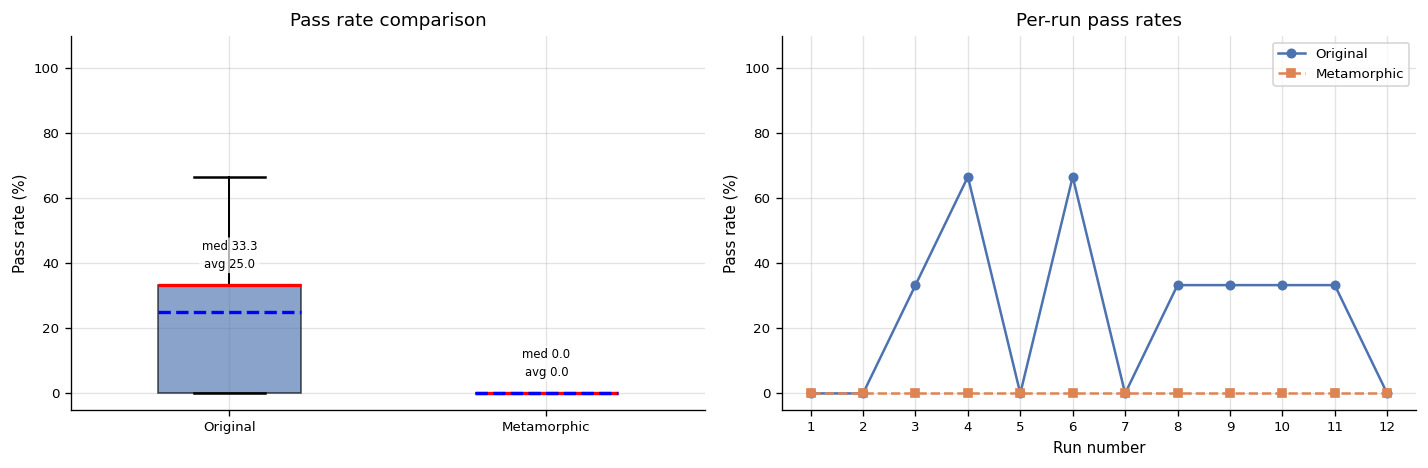

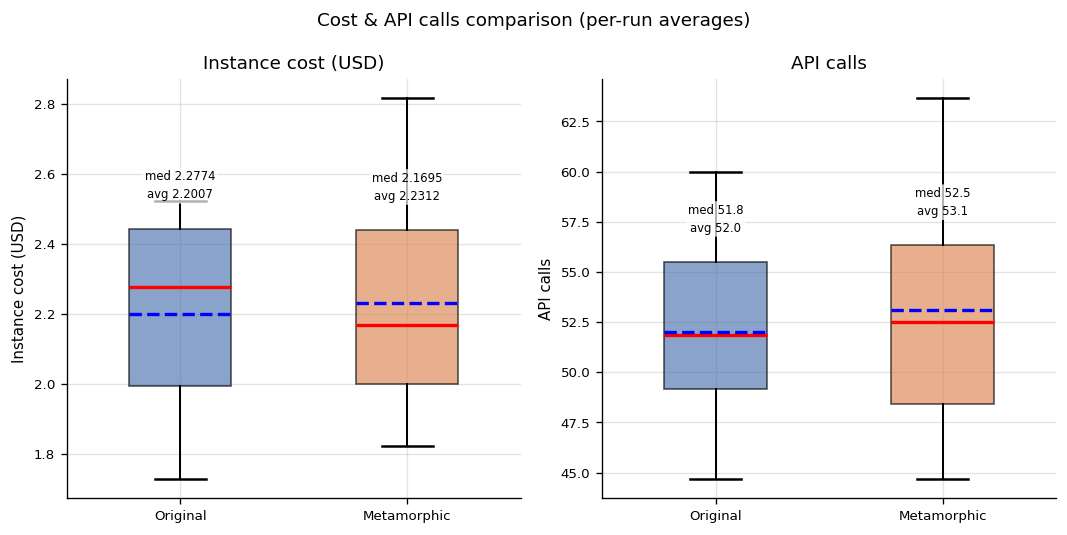

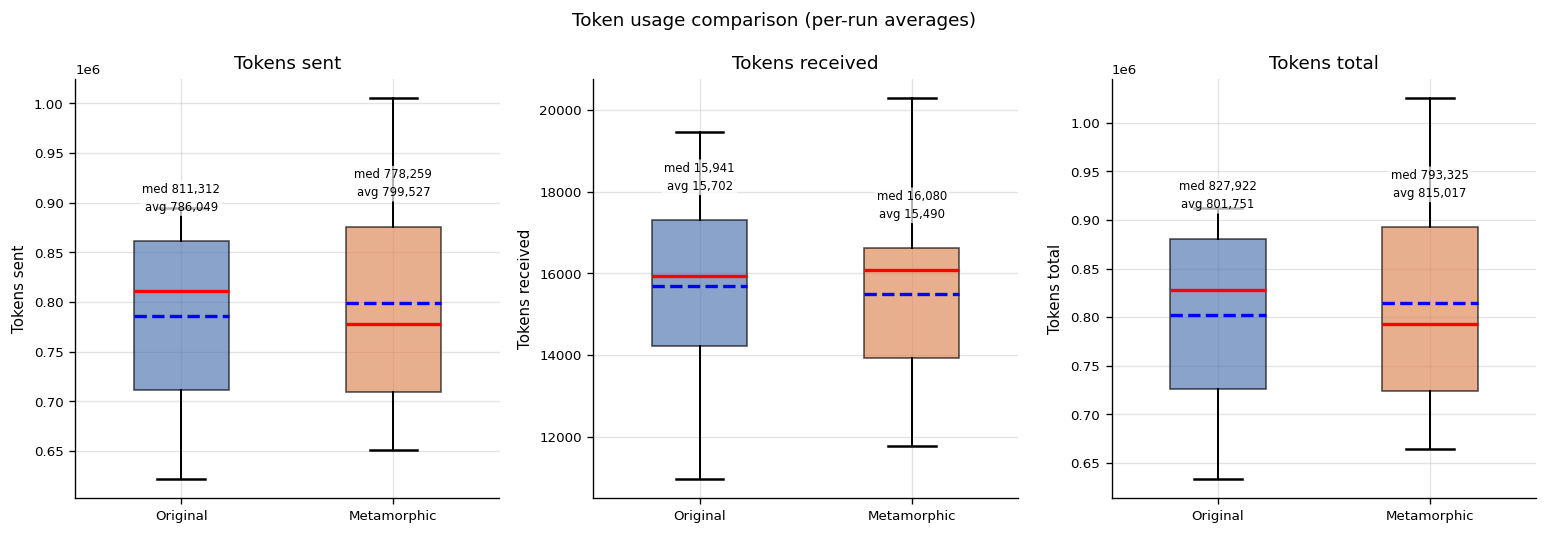

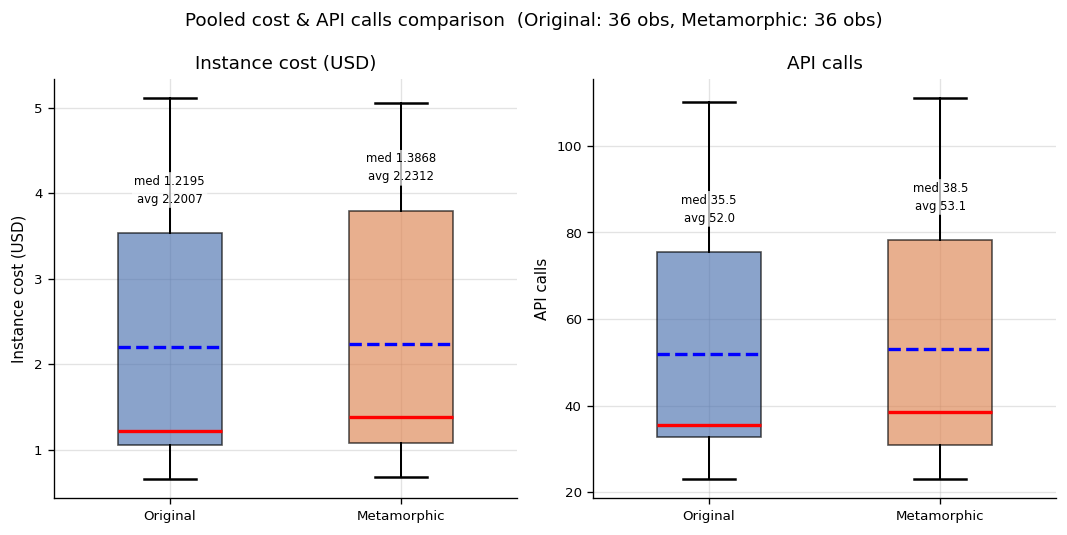

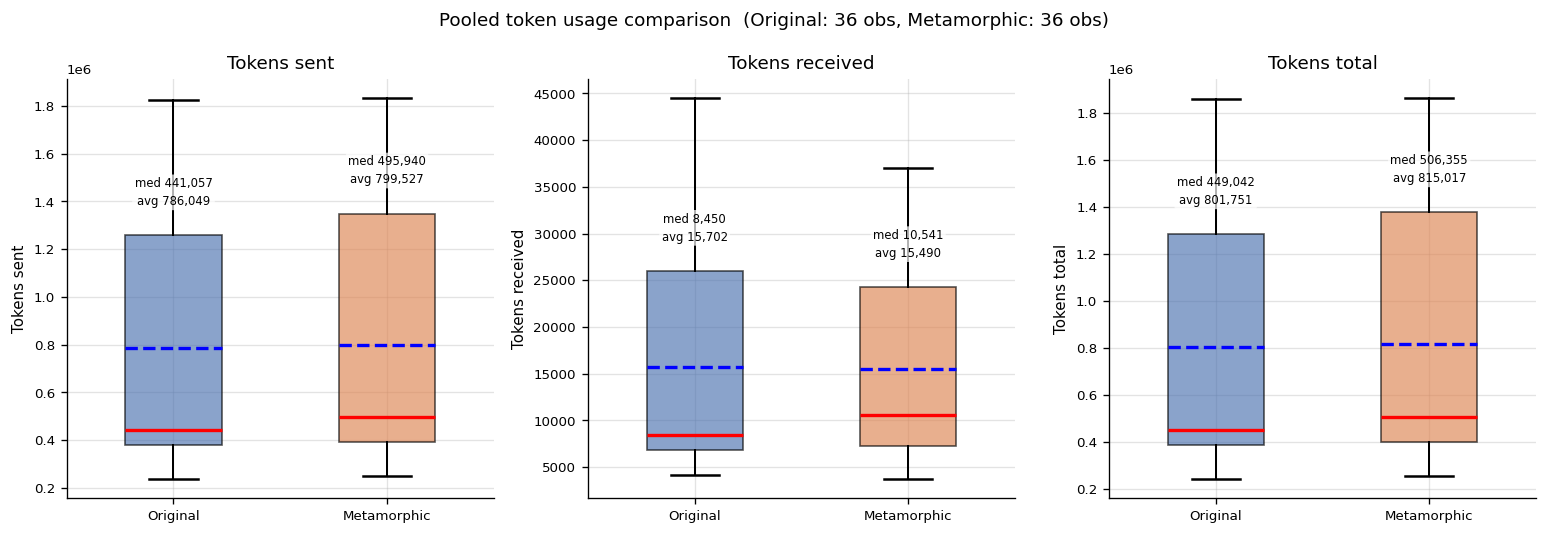


──────────────────────────────────────────────────
  Original  (12 runs × 4 instances)
──────────────────────────────────────────────────
  Pass rate          18.8 %   ± 18.8
  Instance cost    $  2.7051   (median $1.7097)
  Tokens sent         967,289   (median 617,463)
  Tokens received      19,126   (median 11,920)
  Tokens total        986,415
  API calls           62.2   (median 47.0)
──────────────────────────────────────────────────

  Note: M=4 instances/run → pass rate takes only discrete values
  (multiples of 25.0%). The ±std reflects discrete distribution
  spread, not measurement noise.

──────────────────────────────────────────────────
  Metamorphic  (12 runs × 3 instances)
──────────────────────────────────────────────────
  Pass rate           0.0 %   ± 0.0
  Instance cost    $  2.2312   (median $1.3868)
  Tokens sent         799,527   (median 495,940)
  Tokens received      15,490   (median 10,541)
  Tokens total        815,017
  API calls           53.1   (median 38

In [42]:
# ─── Run ──────────────────────────────────────────────────────────────────────
# Edit EVAL_DIR_A / EVAL_DIR_B / LABEL_A / LABEL_B in cell 1 above, then
# re-run this cell.  Set EVAL_DIR_B = None for a single-eval report.

if EVAL_DIR_B is None:
    build_single_report(EVAL_DIR_A, LABEL_A, instance_ids=INSTANCE_IDS)
else:
    build_comparison_report(EVAL_DIR_A, LABEL_A, EVAL_DIR_B, LABEL_B, instance_ids=INSTANCE_IDS)

# Statistical significance — DataFrame display

In [43]:
_print_statistical_significance_dfs = False

if EVAL_DIR_B is None:
    print("DataFrame tables are only available in comparison mode (set EVAL_DIR_B).")
else:
    _print_statistical_significance_dfs = True

In [44]:
# ─── Statistical significance — DataFrame display ─────────────────────────────
# Comparison mode only. Split this cell to display each DataFrame separately.

if _print_statistical_significance_dfs:
    _metrics_a   = load_metrics(EVAL_DIR_A)
    _metrics_b   = load_metrics(EVAL_DIR_B)
    _obs_a       = load_instance_observations(EVAL_DIR_A, instance_ids=INSTANCE_IDS)
    _obs_b       = load_instance_observations(EVAL_DIR_B, instance_ids=INSTANCE_IDS)
    _obs_by_id_a = load_instance_observations_by_id(EVAL_DIR_A, instance_ids=INSTANCE_IDS)
    _obs_by_id_b = load_instance_observations_by_id(EVAL_DIR_B, instance_ids=INSTANCE_IDS)


# helper method to print per-instance metric dataframes
def _show(field_idx: int, expected_field: str, human_label: str) -> pd.DataFrame:
    """Display per-instance stat significance for one metric field."""

    if _print_statistical_significance_dfs is False:
        print(f"Printing of statistical significance is disabled ({expected_field}, {human_label})")
        return

    field, _, _ = _STAT_AGENT_FIELDS[field_idx]
    assert field == expected_field, f"Expected {expected_field!r} at index {field_idx}, got {field!r}"

    assert _obs_by_id_a is not None
    assert _obs_by_id_b is not None

    df = get_stat_significance_per_instance_df(_obs_by_id_a, _obs_by_id_b, field)
    print(f"{human_label}  |  {LABEL_A} vs {LABEL_B}")
    display(df)
    return df


## Overall table (for all metrics)

In [45]:
# ── Overall table ─────────────────────────────────────────────────────────
if _print_statistical_significance_dfs:
    df_overall = get_stat_significance_overall_df(
        _obs_a, _obs_b, _metrics_a, _metrics_b, LABEL_A, LABEL_B
    )
    print(f"Overall (all metrics): {LABEL_A} vs {LABEL_B}")
    display(df_overall)

Overall (all metrics): Original vs Metamorphic


,metric,n_A,n_B,med_A,med_B,p_value,A12,magnitude,significant
0,pass_rate,12,12,25.000000,0.000000,0.002663,0.791667,large,True
1,instance_cost,36,36,1.219463,1.386786,0.539351,NaN,-,False
2,api_calls,36,36,35.500000,38.500000,0.769469,NaN,-,False
3,tokens_sent,36,36,441057.000000,495939.500000,0.502790,NaN,-,False
4,tokens_received,36,36,8450.500000,10541.000000,0.517252,NaN,-,False
5,tokens_total,36,36,449042.500000,506355.000000,0.495638,NaN,-,False


## Per-instance tables (one per metric)

### Pass rate

In [46]:
# ── Per-instance id pass rate ─────────────────────────────────────────────────────────
if _print_statistical_significance_dfs:
    df_per_instance_pass_rate = get_per_instance_pass_rate_df(EVAL_DIR_A, EVAL_DIR_B)
    print(f"Per-instance pass rate  |  {LABEL_A} (pass_rate_A_%)  vs  {LABEL_B} (pass_rate_B_%)")
    display(df_per_instance_pass_rate)

Per-instance pass rate  |  Original (pass_rate_A_%)  vs  Metamorphic (pass_rate_B_%)


,instance_id,n_A,n_B,pass_rate_A_%,pass_rate_B_%,p_value,A12,magnitude,significant,eval_instance_id
0,fasterxml__jackson-core-183,12,12,16.666667,0.0,0.165824,NaN,-,False,fasterxml/jackson-core:pr-183
1,fasterxml__jackson-databind-1923,12,12,33.333333,0.0,0.035722,0.666667,medium,True,fasterxml/jackson-databind:pr-1923
2,mockito__mockito-3129,12,12,25.000000,0.0,0.078018,NaN,-,False,mockito/mockito:pr-3129


### Instance cost

In [47]:
df_instance_cost = _show(0, "instance_cost", "Instance cost")

Instance cost  |  Original vs Metamorphic


,instance_id,n_A,n_B,med_A,med_B,p_value,A12,magnitude,significant
0,fasterxml__jackson-core-183,12,12,1.00860,1.176439,0.193931,NaN,-,False
1,fasterxml__jackson-databind-1923,12,12,1.17392,1.244731,0.885234,NaN,-,False
2,mockito__mockito-3129,12,12,5.01124,4.146806,0.623605,NaN,-,False


### API calls

In [48]:
df_api_calls = _show(1, "api_calls", "API calls")

API calls  |  Original vs Metamorphic


,instance_id,n_A,n_B,med_A,med_B,p_value,A12,magnitude,significant
0,fasterxml__jackson-core-183,12,12,33.5,36.5,0.272030,NaN,-,False
1,fasterxml__jackson-databind-1923,12,12,34.0,32.5,0.663422,NaN,-,False
2,mockito__mockito-3129,12,12,87.5,92.5,1.000000,NaN,-,False


### Tokens sent

In [49]:
df_tokens_sent = _show(2, "tokens_sent", "Tokens sent")

Tokens sent  |  Original vs Metamorphic


,instance_id,n_A,n_B,med_A,med_B,p_value,A12,magnitude,significant
0,fasterxml__jackson-core-183,12,12,367410.0,423931.5,0.214494,NaN,-,False
1,fasterxml__jackson-databind-1923,12,12,417215.0,442458.5,0.885234,NaN,-,False
2,mockito__mockito-3129,12,12,1776063.5,1490558.0,0.930987,NaN,-,False


### Tokens received

In [50]:
df_tokens_received = _show(3, "tokens_received", "Tokens received")

Tokens received  |  Original vs Metamorphic


,instance_id,n_A,n_B,med_A,med_B,p_value,A12,magnitude,significant
0,fasterxml__jackson-core-183,12,12,6136.0,7935.0,0.040404,0.25,large,True
1,fasterxml__jackson-databind-1923,12,12,8363.5,8702.0,0.795012,NaN,-,False
2,mockito__mockito-3129,12,12,33342.5,29595.5,0.193931,NaN,-,False


### Tokens total

In [51]:
df_tokens_total = _show(4, "tokens_total", "Tokens total")

Tokens total  |  Original vs Metamorphic


,instance_id,n_A,n_B,med_A,med_B,p_value,A12,magnitude,significant
0,fasterxml__jackson-core-183,12,12,373415.0,431705.5,0.193931,NaN,-,False
1,fasterxml__jackson-databind-1923,12,12,425940.5,451697.5,0.839860,NaN,-,False
2,mockito__mockito-3129,12,12,1815342.0,1515010.5,0.930987,NaN,-,False
